# Survey Visualizations — Engineering Practices for LLM-Based Systems

Results of the survey conducted for: *"A Roadmap for Tamed Interactions with Large Language Models"*

## Implementation checklist

- [x] Load and remap survey data columns
- [x] **QC — exclude non-LLM respondents** (Q1 = "No")
- [x] **QC — attention check** (Q8: must answer "Disagree")
- [x] **QC — near-zero intra-individual variance** filter
- [x] **QC — consistency check** Q11.a vs Q11.f (negatively-framed pair)
- [x] **Cronbach's alpha** per construct block
- [x] Q1 – LLM experience (pie)
- [x] Q2 – Primary role (bar)
- [x] Q3 – Years of experience (bar)
- [x] Q4 – Self-reported knowledgeability (bar)
- [x] Q5 – Implementation methods (multi-select bar)
- [x] Q6 – Where prompts/interaction logic lives (bar)
- [x] Q7 – Pain-point Likert statements (diverging stacked bar)
- [x] Q8 – Attention check verification
- [x] Q9 – Feature usefulness ratings 1–5 (diverging stacked bar)
- [x] Q10 – Overall DSL usefulness (bar)
- [x] Q11 – Perceived DSL benefits (diverging stacked bar)
- [x] Q12 – Adoption concerns (diverging stacked bar)
- [x] **Friedman test** (role-based; note on applicability with observed groups)
- [x] **Post-hoc Wilcoxon signed-rank** vs contributor baseline
- [ ] Q13, Q14, Q15 — open-ended questions (excluded per author request)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon, mannwhitneyu
from itertools import combinations
from pathlib import Path
import warnings, os

warnings.filterwarnings("ignore")

# ── Path resolution (works whether kernel is started from notebooks/ or repo root) ──
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
FIG_DIR = str(REPO_ROOT / "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Style
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SAVE_FIG = True  # set False to suppress file output

def savefig(name):
    if SAVE_FIG:
        path = os.path.join(FIG_DIR, name)
        plt.savefig(path, bbox_inches="tight")
        print(f"Saved → {path}")

print("REPO_ROOT:", REPO_ROOT)
print("FIG_DIR  :", FIG_DIR)

In [2]:
DATA_PATH = str(REPO_ROOT / "data" /
                "Survey on Engineering Practices for LLM-Based Systems(1-21).xlsx")
raw = pd.read_excel(DATA_PATH)
print(f"Raw shape: {raw.shape}")

# ── Column remapping (by position to avoid encoding / whitespace issues) ──────
COL_MAP = {
    raw.columns[0]:  "id",
    raw.columns[6]:  "q1_llm_exp",
    raw.columns[7]:  "q2_role",
    raw.columns[8]:  "q3_years_exp",
    raw.columns[9]:  "q4_knowledge",
    raw.columns[10]: "q5_impl_methods",
    raw.columns[11]: "q6_prompt_location",
    # Q7: 6 pain-point Likert items (a–f)
    raw.columns[12]: "q7a_hard_to_reason",
    raw.columns[13]: "q7b_debug_hard",
    raw.columns[14]: "q7c_invalid_output_propagates",
    raw.columns[15]: "q7d_hard_to_constrain",
    raw.columns[16]: "q7e_maintain_hard",
    raw.columns[17]: "q7f_separation_helps",
    # Q8: Attention check
    raw.columns[18]: "q8_attention",
    # Q9: 5 feature usefulness items (a–e), scale 1–5
    raw.columns[19]: "q9a_explicit_workflow",
    raw.columns[20]: "q9b_static_analysis",
    raw.columns[21]: "q9c_output_constraints",
    raw.columns[22]: "q9d_builtin_validation",
    raw.columns[23]: "q9e_separation_llm_control",
    # Q10: Overall DSL usefulness (1–5)
    raw.columns[24]: "q10_dsl_useful",
    # Q11: 6 DSL benefit statements (a–f)
    raw.columns[25]: "q11a_debug_improve",       # positive framing
    raw.columns[26]: "q11b_reliability_improve",
    raw.columns[27]: "q11c_maintenance_easier",
    raw.columns[28]: "q11d_testing_improve",
    raw.columns[29]: "q11e_no_benefit",           # negative framing
    raw.columns[30]: "q11f_bugs_harder",          # negative framing (consistency check vs q11a)
    # Q12: 5 adoption concern items (a–e)
    raw.columns[31]: "q12a_learning_curve",
    raw.columns[32]: "q12b_integration",
    raw.columns[33]: "q12c_performance",
    raw.columns[34]: "q12d_flexibility",
    raw.columns[35]: "q12e_not_needed",
    # Q13–Q15: open-ended (not visualised)
    raw.columns[36]: "q13_open_challenge",
    raw.columns[37]: "q14_open_adoption",
    raw.columns[38]: "q15_open_comments",
}
df = raw.rename(columns=COL_MAP).copy()
print(f"Columns remapped. Working columns: {[c for c in df.columns if c.startswith('q')]}")
df.head(3)

Raw shape: (21, 39)
Columns remapped. Working columns: ['q1_llm_exp', 'q2_role', 'q3_years_exp', 'q4_knowledge', 'q5_impl_methods', 'q6_prompt_location', 'q7a_hard_to_reason', 'q7b_debug_hard', 'q7c_invalid_output_propagates', 'q7d_hard_to_constrain', 'q7e_maintain_hard', 'q7f_separation_helps', 'q8_attention', 'q9a_explicit_workflow', 'q9b_static_analysis', 'q9c_output_constraints', 'q9d_builtin_validation', 'q9e_separation_llm_control', 'q10_dsl_useful', 'q11a_debug_improve', 'q11b_reliability_improve', 'q11c_maintenance_easier', 'q11d_testing_improve', 'q11e_no_benefit', 'q11f_bugs_harder', 'q12a_learning_curve', 'q12b_integration', 'q12c_performance', 'q12d_flexibility', 'q12e_not_needed', 'q13_open_challenge', 'q14_open_adoption', 'q15_open_comments']


,id,Ora di inizio,Ora di completamento,Posta elettronica,Nome,Ora ultima modifica,q1_llm_exp,q2_role,q3_years_exp,q4_knowledge,...,q11e_no_benefit,q11f_bugs_harder,q12a_learning_curve,q12b_integration,q12c_performance,q12d_flexibility,q12e_not_needed,q13_open_challenge,q14_open_adoption,q15_open_comments
0,1,2026-05-20 16:15:24,2026-05-20 16:31:00,anonymous,NaN,NaN,"Yes, prototypes/research",Researcher,3-5,Knowledgeable,...,Strongly disagree,Disagree,Indifferent,Concerned,Concerned,Concerned,Indifferent,1. The gap between syntax correctness and sema...,Yes. For research and engineering workflows wh...,Could improve the story with a foundation mode...
1,2,2026-05-20 16:25:20,2026-05-20 16:32:18,anonymous,NaN,NaN,"Yes, prototypes/research",Researcher,3-5,Knowledgeable,...,Disagree,Neutral,Concerned,Concerned,Unconcerned,Concerned,Concerned,Reliability of outputs (indeterminism of the s...,Depends on the ease of integration and the lan...,NaN
2,3,2026-05-20 16:23:54,2026-05-20 16:34:16,anonymous,NaN,NaN,"Yes, in production systems",Software engineer,1–2,Knowledgeable,...,Strongly disagree,Strongly disagree,Concerned,Very concerned,Concerned,Concerned,Indifferent,Parsing/understanding LLM outputs. When nondet...,"Yes, if this is not another abstraction layer ...",NaN


## Data Quality Control

Four filters are applied in sequence:

1. **Exclude non-LLM respondents** – participants who answered "No" to Q1 are routed out of the survey and their rows contain all-NaN responses.
2. **Attention check (Q8)** – participants were asked to select "Disagree" on a dummy item. Rows with any other answer are excluded.
3. **Near-zero intra-individual variance** – for each respondent, compute the variance across all Likert-scale responses. A variance of 0 (or very close to 0) indicates straight-lining / inattentive responding and those rows are dropped.
4. **Consistency check (Q11.a vs Q11.f)** – Q11.a ("Debugging will improve") and Q11.f ("Finding bugs will be harder") are logically contradictory; a respondent who strongly agrees with both is flagged. This is reported but not automatically excluded, as it is used as a diagnostic.

After filtering, Cronbach's α is reported per construct block.

In [3]:
# ── Likert encoding helpers ───────────────────────────────────────────────────
AGREE5 = ["Strongly disagree", "Disagree", "Neither agree nor disagree", "Agree", "Strongly agree"]
AGREE5_NUM = {v: i+1 for i, v in enumerate(AGREE5)}

BENEFIT5 = ["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"]
BENEFIT5_NUM = {v: i+1 for i, v in enumerate(BENEFIT5)}

CONCERN5 = ["Very unconcerned", "Unconcerned", "Indifferent", "Concerned", "Very concerned"]
CONCERN5_NUM = {v: i+1 for i, v in enumerate(CONCERN5)}

Q7_COLS  = ["q7a_hard_to_reason","q7b_debug_hard","q7c_invalid_output_propagates",
            "q7d_hard_to_constrain","q7e_maintain_hard","q7f_separation_helps"]
Q9_COLS  = ["q9a_explicit_workflow","q9b_static_analysis","q9c_output_constraints",
            "q9d_builtin_validation","q9e_separation_llm_control"]
Q11_COLS = ["q11a_debug_improve","q11b_reliability_improve","q11c_maintenance_easier",
            "q11d_testing_improve","q11e_no_benefit","q11f_bugs_harder"]
Q12_COLS = ["q12a_learning_curve","q12b_integration","q12c_performance",
            "q12d_flexibility","q12e_not_needed"]

ALL_LIKERT_COLS = Q7_COLS + Q9_COLS + Q11_COLS + Q12_COLS

# ── Step 1: exclude non-LLM respondents ──────────────────────────────────────
n_start = len(df)
df = df[df["q1_llm_exp"] != "No"].copy()
print(f"Step 1 – non-LLM excluded:       {n_start} → {len(df)} rows")

# ── Step 2: attention check (Q8 must be "Disagree") ──────────────────────────
before = len(df)
df = df[df["q8_attention"].str.strip() == "Disagree"].copy()
print(f"Step 2 – attention check failed: {before} → {len(df)} rows "
      f"({before - len(df)} removed)")

# ── Step 3: near-zero intra-individual variance ───────────────────────────────
# Encode all Likert columns to numeric for variance computation
def encode_likert_row(row):
    vals = []
    for c in Q7_COLS:
        vals.append(AGREE5_NUM.get(str(row.get(c, "")).strip(), np.nan))
    for c in Q9_COLS:
        v = row.get(c, np.nan)
        vals.append(float(v) if pd.notna(v) else np.nan)
    for c in Q11_COLS:
        vals.append(BENEFIT5_NUM.get(str(row.get(c, "")).strip(), np.nan))
    for c in Q12_COLS:
        vals.append(CONCERN5_NUM.get(str(row.get(c, "")).strip(), np.nan))
    return vals

likert_matrix = df.apply(encode_likert_row, axis=1, result_type="expand")
likert_matrix.index = df.index
df["_ind_variance"] = likert_matrix.var(axis=1)

VARIANCE_THRESHOLD = 0.10
low_var = df[df["_ind_variance"] < VARIANCE_THRESHOLD]
before = len(df)
df = df[df["_ind_variance"] >= VARIANCE_THRESHOLD].copy()
print(f"Step 3 – near-zero variance:     {before} → {len(df)} rows "
      f"({before - len(df)} removed, threshold={VARIANCE_THRESHOLD})")
print(f"         Variance range (kept): [{df['_ind_variance'].min():.2f}, {df['_ind_variance'].max():.2f}]")

# ── Step 4: consistency check Q11.a vs Q11.f (diagnostic only) ───────────────
# Q11.a: "Debugging will improve" (positive)
# Q11.f: "Finding bugs will be harder" (negative)
# Inconsistency: both rated "Agree" or "Strongly agree"
pos_responses = {"Agree", "Strongly agree"}
inconsistent = df[
    df["q11a_debug_improve"].isin(pos_responses) &
    df["q11f_bugs_harder"].isin(pos_responses)
]
print(f"\nStep 4 – Q11.a/Q11.f consistency check: {len(inconsistent)} inconsistent respondent(s)")
if len(inconsistent) > 0:
    print("  IDs:", inconsistent["id"].tolist())
    print("  → These rows are flagged but retained; review manually before reporting.")

print(f"\n✓ Final sample for analysis: N = {len(df)}")

Step 1 – non-LLM excluded:       21 → 20 rows
Step 2 – attention check failed: 20 → 20 rows (0 removed)
Step 3 – near-zero variance:     20 → 20 rows (0 removed, threshold=0.1)
         Variance range (kept): [0.35, 1.90]

Step 4 – Q11.a/Q11.f consistency check: 0 inconsistent respondent(s)

✓ Final sample for analysis: N = 20


In [4]:
def cronbach_alpha(data_matrix):
    """
    Compute Cronbach's α from a 2-D array (rows=respondents, cols=items).
    Returns α and 95% CI via Fisher's z-transformation bootstrap is omitted
    for simplicity; standard formula only.
    """
    d = np.array(data_matrix, dtype=float)
    d = d[~np.isnan(d).any(axis=1)]  # listwise deletion
    n, k = d.shape
    if n < 2 or k < 2:
        return np.nan
    item_var = d.var(axis=0, ddof=1)
    total_var = d.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

# Re-extract encoded matrix after filtering
likert_matrix = df.apply(encode_likert_row, axis=1, result_type="expand")
likert_matrix.index = df.index
n_items = [len(Q7_COLS), len(Q9_COLS), len(Q11_COLS), len(Q12_COLS)]
col_slices = []
start = 0
for n in n_items:
    col_slices.append(list(range(start, start + n)))
    start += n

blocks = {
    "Q7  Pain points (6 items)":      likert_matrix.iloc[:, col_slices[0]].values,
    "Q9  Feature usefulness (5 items)": likert_matrix.iloc[:, col_slices[1]].values,
    "Q11 DSL benefits (6 items)":     likert_matrix.iloc[:, col_slices[2]].values,
    "Q12 Adoption concerns (5 items)": likert_matrix.iloc[:, col_slices[3]].values,
}

print("Cronbach's α per construct block")
print("-" * 45)
for label, mat in blocks.items():
    a = cronbach_alpha(mat)
    interp = ("excellent" if a >= .9 else "good" if a >= .8 else
              "acceptable" if a >= .7 else "questionable" if a >= .6 else
              "poor" if a >= .5 else "unacceptable")
    print(f"  {label}: α = {a:.3f}  ({interp})")

Cronbach's α per construct block
---------------------------------------------
  Q7  Pain points (6 items): α = 0.745  (acceptable)
  Q9  Feature usefulness (5 items): α = 0.617  (questionable)
  Q11 DSL benefits (6 items): α = -0.677  (unacceptable)
  Q12 Adoption concerns (5 items): α = 0.191  (unacceptable)


In [ ]:
# ── Figure size constants ─────────────────────────────────────────────────────
W_DIV    = 10                    # width shared by all diverging stacked bar plots
W_SIMPLE = W_DIV * 2 / 3        # width for Q1–Q6 simple charts (≈ 6.67)
H_SIMPLE = W_SIMPLE / 2         # height for Q1–Q6 (half of width, ≈ 3.33)

# ── Colour palettes ───────────────────────────────────────────────────────────
# Diverging 5-point: neg-to-pos, neutral grey
DIV5_COLORS = ["#d73027", "#fc8d59", "#d9d9d9", "#91bfdb", "#4575b4"]
DIV5_COLORS_CONCERN = ["#4575b4", "#91bfdb", "#d9d9d9", "#fc8d59", "#d73027"]  # concern: blue=low

QUAL_COLORS = plt.cm.tab10.colors

# ── Generic diverging stacked bar chart ──────────────────────────────────────
def plot_diverging_stacked(counts_df, categories, colors, item_labels,
                           title="", xlabel="Proportion of respondents",
                           figsize=(W_DIV, None), neutral_idx=2, ax=None):
    """
    counts_df : DataFrame, rows=items, cols=categories (in order neg→pos)
    categories : list of category strings (same order as cols)
    colors     : list of colors matching categories
    item_labels: list of y-axis labels (same length as rows)
    neutral_idx: index of the neutral/midpoint category (used to centre bars)
    """
    n_items = len(item_labels)
    if figsize[1] is None:
        figsize = (figsize[0], max(3, 0.55 * n_items + 1.2))

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)

    props = counts_df.div(counts_df.sum(axis=1), axis=0)  # proportions

    # Left edge for each bar: half of neutral centred at 0,
    # negative categories extend left, positive extend right
    lefts = np.zeros(n_items)
    neg_half = props.iloc[:, neutral_idx].values / 2  # half of neutral
    for i in range(neutral_idx - 1, -1, -1):
        lefts -= props.iloc[:, i].values
    lefts -= neg_half  # shift so neutral straddles 0

    current = lefts.copy()
    bars = []
    for i, (cat, col) in enumerate(zip(categories, colors)):
        widths = props.iloc[:, i].values
        b = ax.barh(range(n_items), widths, left=current,
                    color=col, edgecolor="white", linewidth=0.5, label=cat)
        bars.append(b)
        for j, (w, c) in enumerate(zip(widths, current)):
            raw_count = int(counts_df.iloc[j, i])
            if w >= 0.06 and raw_count > 0:
                ax.text(c + w / 2, j, str(raw_count),
                        ha="center", va="center", fontsize=9.5, color="white",
                        fontweight="bold")
        current += widths

    # zorder=0 keeps the centre line behind the bars
    ax.axvline(0, color="black", linewidth=0.8, zorder=0)
    ax.set_yticks(range(n_items))
    ax.set_yticklabels(item_labels, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_xlim(-1.05, 1.05)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(x):.0%}"))
    ax.set_title(title, fontsize=13, pad=8)
    ax.invert_yaxis()

    ax.legend(handles=bars, labels=categories, loc="lower left",
              fontsize=10, framealpha=0.8, ncol=1, bbox_to_anchor=(0.0, 0.0))

    if standalone:
        #  plt.tight_layout()
    return ax


def count_multiselect(series, sep=";"):
    """Explode a semicolon-delimited multi-select column into individual counts."""
    return (
        series.dropna()
              .str.split(sep)
              .explode()
              .str.strip()
              .value_counts()
    )


print(f"Figure sizes — diverging: {W_DIV} in wide | simple (Q1–Q6): {W_SIMPLE:.2f} × {H_SIMPLE:.2f} in")

## Section 1 — Respondent Profile (Q1–Q6)

In [ ]:
# ── Q1: LLM experience ────────────────────────────────────────────────────────
q1_counts = df["q1_llm_exp"].value_counts()
ORDER_Q1 = [
    "Yes, prototypes/research",
    "Yes, in production systems",
    "No",
]

fig, ax = plt.subplots(figsize=(W_SIMPLE, H_SIMPLE))
q1_plot = q1_counts.reindex([o for o in ORDER_Q1 if o in q1_counts.index], fill_value=0)
wedges, texts, autotexts = ax.pie(
    q1_plot.values,
    labels=q1_plot.index,
    autopct=lambda p: f"{p:.0f}%\n(n={int(round(p * q1_plot.sum() / 100))})",
    colors=["#4575b4", "#91bfdb", "#d9d9d9"],
    startangle=90,
    pctdistance=0.72,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
for wedge, at in zip(wedges, autotexts):
    at.set_fontsize(10.5)
    # choose white or black text based on wedge luminance
    hex_color = wedge.get_facecolor()
    r, g, b = hex_color[0], hex_color[1], hex_color[2]
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    at.set_color("white" if luminance < 0.55 else "black")
ax.set_title("Q1 – Have you worked with LLMs in software systems?", fontsize=12, pad=10)
#  plt.tight_layout()
savefig("q1_llm_experience.pdf")
plt.show()

In [ ]:
# ── Q2: Primary role ─────────────────────────────────────────────────────────
q2_counts = df["q2_role"].value_counts()

fig, ax = plt.subplots(figsize=(W_SIMPLE, H_SIMPLE))
bars = ax.barh(q2_counts.index[::-1], q2_counts.values[::-1], color="#4575b4")
for bar, val in zip(bars, q2_counts.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=11)
ax.set_xlabel("Number of respondents", fontsize=11)
ax.set_xlim(0, q2_counts.max() + 2)
ax.set_title("Q2 – What is your primary role?", fontsize=12, pad=6)
#  plt.tight_layout()
savefig("q2_role.pdf")
plt.show()

In [ ]:
# ── Q3: Years of experience ───────────────────────────────────────────────────
ORDER_Q3 = ["< 1 year", "1–2", "3-5", ">5"]
q3_counts = df["q3_years_exp"].value_counts().reindex(ORDER_Q3, fill_value=0)

fig, ax = plt.subplots(figsize=(W_SIMPLE, H_SIMPLE))
bars = ax.barh(q3_counts.index, q3_counts.values, color="#4575b4")
for bar, val in zip(bars, q3_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=11)
ax.set_xlabel("Number of respondents", fontsize=11)
ax.set_xlim(0, q3_counts.max() + 2)
ax.set_title("Q3 – Years of experience with LLM-based systems", fontsize=12, pad=6)
#  plt.tight_layout()
savefig("q3_years_experience.pdf")
plt.show()

# ── Q4: Self-reported knowledgeability (all 4 levels) ─────────────────────────
ORDER_Q4 = ["Highly unaware", "Unaware", "Knowledgeable", "Highly knowledgeable"]
Q4_COLORS = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]
q4_counts = df["q4_knowledge"].value_counts().reindex(ORDER_Q4, fill_value=0)

fig, ax = plt.subplots(figsize=(W_SIMPLE, H_SIMPLE))
bars = ax.barh(q4_counts.index, q4_counts.values, color=Q4_COLORS)
for bar, val in zip(bars, q4_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=11)
ax.set_xlabel("Number of respondents", fontsize=11)
ax.set_xlim(0, q4_counts.max() + 2)
ax.set_title("Q4 – How knowledgeable are you about the topic?", fontsize=12, pad=6)
#  plt.tight_layout()
savefig("q4_knowledgeability.pdf")
plt.show()

In [ ]:
# ── Q5: Implementation methods (multi-select) ────────────────────────────────
q5_counts = count_multiselect(df["q5_impl_methods"], sep=";")
q5_counts = q5_counts[q5_counts.index != ""]   # drop empty-string artifact from trailing semicolons
LABEL_Q5 = {
    "Prompt templates (e.g., f-strings, Jinja2)": "Prompt templates",
    "Hardcoded prompts in application code": "Hardcoded prompts",
    "LLM orchestration frameworks (e.g., LangChain, Semantic Kernel, LlamaIndex, etc.)": "Frameworks (LangChain, etc.)",
    "DSL-like tools for structured generation (e.g., Guidance, Guardrails, Outlines, etc.)": "DSL-like tools",
    "Low-code / no-code platforms (e.g., n8n, Flowise, etc.)": "Low-code platforms",
    "Altro": "Other",
    "Other": "Other",
    "Custom frameworks": "Other",
}
q5_counts.index = [LABEL_Q5.get(i, i) for i in q5_counts.index]
q5_counts = q5_counts.groupby(q5_counts.index).sum()  # merge duplicate "Other" entries
q5_counts = q5_counts.sort_values()

fig, ax = plt.subplots(figsize=(W_SIMPLE, H_SIMPLE))
bars = ax.barh(q5_counts.index, q5_counts.values, color="#4575b4")
for bar, val in zip(bars, q5_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=11)
ax.set_xlabel("Number of respondents (multi-select)", fontsize=11)
ax.set_xlim(0, q5_counts.max() + 2.5)
ax.set_title("Q5 – How do you implement LLM interactions today?", fontsize=12, pad=6)
#  plt.tight_layout()
savefig("q5_implementation_methods.pdf")
plt.show()

# ── Q6: Where prompts/interaction logic lives ─────────────────────────────────
q6_counts = df["q6_prompt_location"].value_counts()

fig, ax = plt.subplots(figsize=(W_SIMPLE, H_SIMPLE))
bars = ax.barh(q6_counts.index[::-1], q6_counts.values[::-1], color="#4575b4")
for bar, val in zip(bars, q6_counts.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=11)
ax.set_xlabel("Number of respondents", fontsize=11)
ax.set_xlim(0, q6_counts.max() + 2.5)
ax.set_title("Q6 – Where is prompt/interaction logic handled?", fontsize=12, pad=6)
#  plt.tight_layout()
savefig("q6_prompt_location.pdf")
plt.show()

## Section 2 — Pain Points (Q7)

Six Likert statements probing pain points when developing LLM-based systems.  
Scale: Strongly disagree → Disagree → Neither agree nor disagree → Agree → Strongly agree.

Saved → /home/vincenzoscotti/PycharmProjects/tosem_roadmap_to_2030/figures/q7_pain_points.pdf


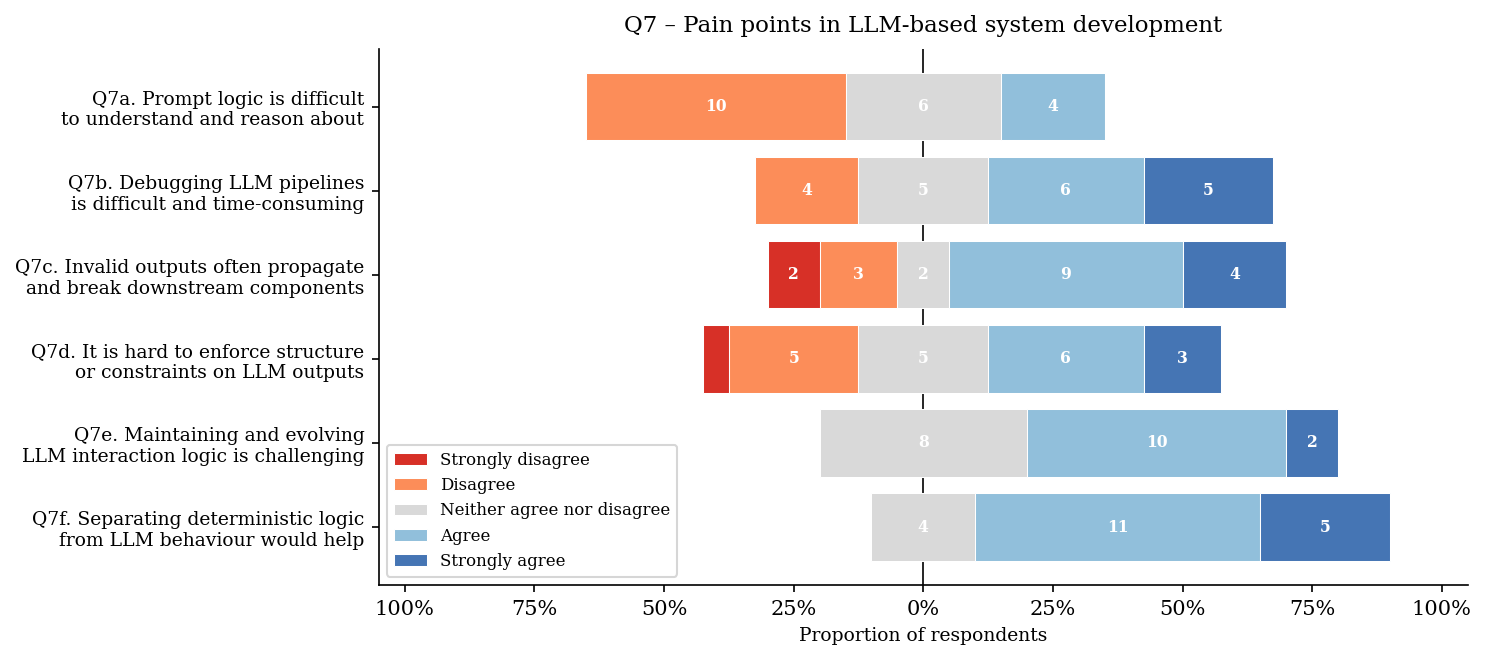

In [10]:
Q7_LABELS = [
    "Q7a. Prompt logic is difficult\nto understand and reason about",
    "Q7b. Debugging LLM pipelines\nis difficult and time-consuming",
    "Q7c. Invalid outputs often propagate\nand break downstream components",
    "Q7d. It is hard to enforce structure\nor constraints on LLM outputs",
    "Q7e. Maintaining and evolving\nLLM interaction logic is challenging",
    "Q7f. Separating deterministic logic\nfrom LLM behaviour would help",
]
Q7_CATS = AGREE5

q7_counts = pd.DataFrame(
    {cat: [df[c].value_counts().get(cat, 0) for c in Q7_COLS] for cat in Q7_CATS},
    index=Q7_LABELS,
)

plot_diverging_stacked(
    q7_counts, Q7_CATS, DIV5_COLORS, Q7_LABELS,
    title="Q7 – Pain points in LLM-based system development",
    figsize=(10, None),
)
savefig("q7_pain_points.pdf")
plt.show()

## Section 3 — Attention Check (Q8)

Q8 was a validity trap: participants were explicitly asked to select "Disagree". Any other response triggers exclusion (applied in the QC step above). The chart below confirms the outcome for the retained sample.

In [11]:
q8_counts = df["q8_attention"].value_counts()
print("Q8 attention check responses (retained sample):")
print(q8_counts.to_string())
print(f"\nAll {len(df)} retained respondents selected 'Disagree' ✓" 
      if (q8_counts.index == ["Disagree"]).all() else "⚠ Unexpected values found")

Q8 attention check responses (retained sample):
q8_attention
Disagree    20

All 20 retained respondents selected 'Disagree' ✓


## Section 4 — Feature Usefulness & Overall DSL Adoption (Q9, Q10)

**Q9** asks respondents to rate the usefulness of five specific LSL features on a 1 (low) to 5 (high) scale.  
**Q10** asks for an overall usefulness rating of the DSL concept (same 1–5 scale).

For diverging bars the midpoint is 3; ratings 1–2 extend left, 4–5 extend right.

In [ ]:
Q9_LABELS = [
    "Q9a. Explicit representation\nof LLM interaction workflows",
    "Q9b. Static analysis\nof interaction logic",
    "Q9c. Output constraints\nvia schemas / grammars",
    "Q9d. Built-in validation\nof outputs",
    "Q9e. Separation between\nLLM calls and control logic",
]
SCALE15 = [1, 2, 3, 4, 5]
SCALE15_STR = ["1 – Not useful", "2", "3 – Neutral", "4", "5 – Very useful"]
SCALE15_COLORS = DIV5_COLORS

# value_counts on numeric columns may return float keys; cast to int
q9_counts = pd.DataFrame(
    {s: [df[c].value_counts().get(s, df[c].value_counts().get(float(s), 0)) for c in Q9_COLS]
     for s in SCALE15},
    index=Q9_LABELS,
)
q9_counts.columns = SCALE15_STR

plot_diverging_stacked(
    q9_counts, SCALE15_STR, SCALE15_COLORS, Q9_LABELS,
    title="Q9 – Perceived usefulness of LSL features (1–5)",
    neutral_idx=2,
)
savefig("q9_feature_usefulness.pdf")
plt.show()

# ── Q10: Overall DSL usefulness ───────────────────────────────────────────────
# Same width as diverging stacked plots; auto-height matches the same formula (5 items)
_q10_h = max(3, 0.55 * 5 + 1.2)
q10_raw = df["q10_dsl_useful"].dropna().astype(int)
q10_counts = q10_raw.value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)

fig, ax = plt.subplots(figsize=(W_DIV, _q10_h))
bars = ax.barh([str(i) for i in q10_counts.index],
               q10_counts.values,
               color=[DIV5_COLORS[i - 1] for i in q10_counts.index])
for bar, val in zip(bars, q10_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=11)
ax.set_xlabel("Number of respondents", fontsize=11)
ax.set_ylabel("Usefulness rating (1 = low, 5 = high)", fontsize=11)
ax.set_xlim(0, q10_counts.max() + 2)
ax.set_title("Q10 – Overall: how useful would this DSL approach be?", fontsize=12, pad=6)

legend_patches = [mpatches.Patch(color=DIV5_COLORS[i - 1], label=lbl)
                  for i, lbl in zip(SCALE15, SCALE15_STR)]
ax.legend(handles=legend_patches, loc="lower right", fontsize=10, framealpha=0.8)

#  plt.tight_layout()
savefig("q10_overall_dsl_usefulness.pdf")
plt.show()

## Section 5 — Perceived DSL Benefits (Q11)

Six statements about expected benefits of adopting LSL/DSL.  
Scale: Strongly disagree → Disagree → Neutral → Agree → Strongly agree.

**Note:** Q11.e ("No benefit is expected") and Q11.f ("Finding bugs will be harder") are negatively framed items used as an internal consistency check against Q11.a ("Debugging will improve").

In [ ]:
Q11_LABELS = [
    "Q11a. Debugging will improve ✓",
    "Q11b. Reliability will improve ✓",
    "Q11c. Maintenance will be easier ✓",
    "Q11d. Testing / verification will improve ✓",
    "Q11e. No benefit is expected ✗ (neg.)",
    "Q11f. Finding bugs will be harder ✗ (neg.)",
]
Q11_CATS = BENEFIT5

q11_counts = pd.DataFrame(
    {cat: [df[c].value_counts().get(cat, 0) for c in Q11_COLS] for cat in Q11_CATS},
    index=Q11_LABELS,
)

ax = plot_diverging_stacked(
    q11_counts, Q11_CATS, DIV5_COLORS, Q11_LABELS,
    title="Q11 – Perceived benefits of adopting LSL/DSL",
    figsize=(10, None), neutral_idx=2,
)
# move legend to the right side
ax.legend(
    handles=[mpatches.Patch(color=c, label=l) for c, l in zip(DIV5_COLORS, Q11_CATS)],
    loc="lower right", fontsize=10, framealpha=0.8, ncol=1, bbox_to_anchor=(1.0, 0.0),
)
savefig("q11_dsl_benefits.pdf")
plt.show()

## Section 6 — Adoption Concerns (Q12)

Five items measuring how concerned respondents are about barriers to adopting a DSL for LLM interactions.  
Scale: Very unconcerned → Unconcerned → Indifferent → Concerned → Very concerned.

Higher values (right side of bars) indicate greater concern.

Saved → /home/vincenzoscotti/PycharmProjects/tosem_roadmap_to_2030/figures/q12_adoption_concerns.pdf


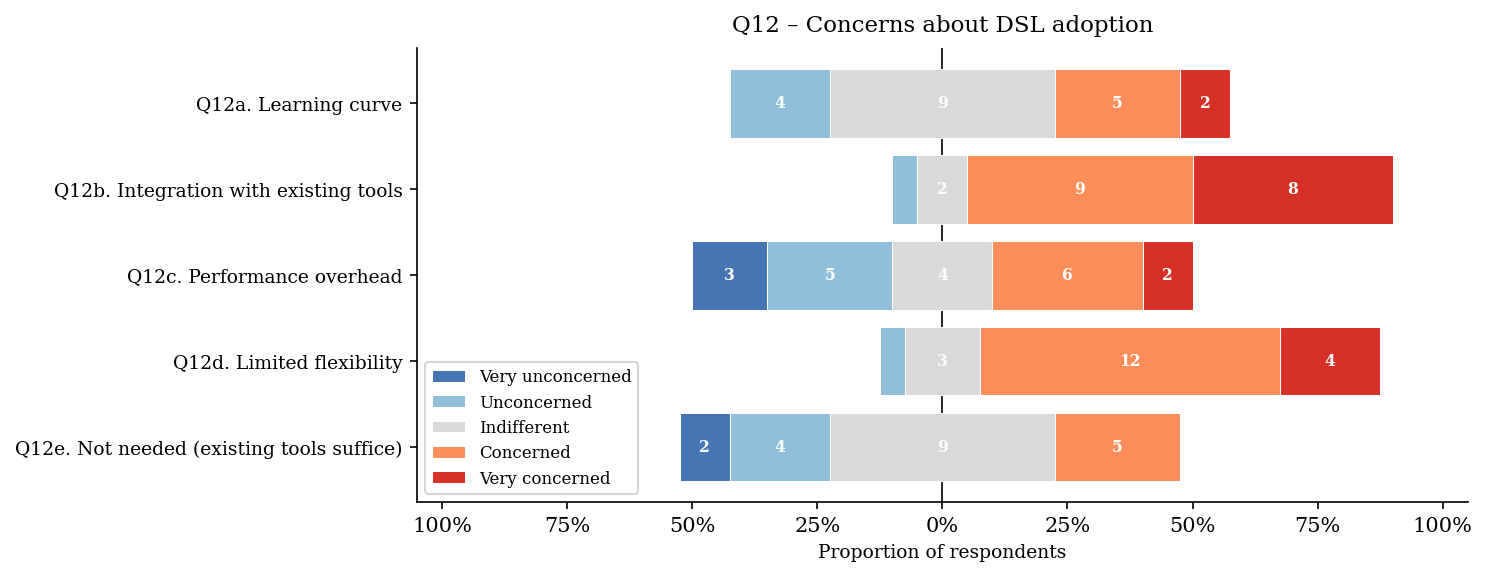

In [14]:
Q12_LABELS = [
    "Q12a. Learning curve",
    "Q12b. Integration with existing tools",
    "Q12c. Performance overhead",
    "Q12d. Limited flexibility",
    "Q12e. Not needed (existing tools suffice)",
]
Q12_CATS = CONCERN5

q12_counts = pd.DataFrame(
    {cat: [df[c].value_counts().get(cat, 0) for c in Q12_COLS] for cat in Q12_CATS},
    index=Q12_LABELS,
)

# Concern scale: blue=low concern, red=high concern
plot_diverging_stacked(
    q12_counts, Q12_CATS, DIV5_COLORS_CONCERN, Q12_LABELS,
    title="Q12 – Concerns about DSL adoption",
    figsize=(10, None), neutral_idx=2,
)
savefig("q12_adoption_concerns.pdf")
plt.show()

## Section 7 — Statistical Tests: Role-based Differences

### Design note

The paper describes a **Friedman test** to detect group-level differences across roles, followed by **post-hoc pairwise Wilcoxon signed-rank tests** comparing specialised roles against a generic "contributor" baseline.

Two important observations about the observed data:

1. **Only two roles received responses**: *Researcher* (n=13) and *Software engineer* (n=7). None of the other role options (ML/AI engineer, DevOps, QA engineer, product manager, generic contributor) were selected. With only two groups, the Friedman test — which requires ≥ 3 treatment groups in a repeated-measures block design — is not applicable. The **Mann–Whitney U test** is the appropriate non-parametric substitute for two independent groups, and it is equivalent to the two-sample Wilcoxon rank-sum test used for pairwise comparisons in the post-hoc step. Results are reported for completeness; given the small group sizes, statistical power is low.

2. **"Contributor" baseline absent**: because no respondent selected that role, the planned post-hoc comparison against the contributor baseline cannot be performed. Instead, results are reported for the Researcher vs Software engineer contrast.

If future data collection yields ≥ 3 roles, replace `mannwhitneyu` with `friedmanchisquare` across the role groups and use Wilcoxon signed-rank for pairwise post-hoc tests with Bonferroni correction.

In [15]:
# ── Encode all Likert columns numerically ─────────────────────────────────────
df_enc = df.copy()
for c in Q7_COLS:
    df_enc[c] = df_enc[c].map(AGREE5_NUM)
for c in Q9_COLS:
    df_enc[c] = pd.to_numeric(df_enc[c], errors="coerce")
for c in Q11_COLS:
    df_enc[c] = df_enc[c].map(BENEFIT5_NUM)
for c in Q12_COLS:
    df_enc[c] = df_enc[c].map(CONCERN5_NUM)

# Composite score per respondent per block (mean of items)
df_enc["score_q7"]  = df_enc[Q7_COLS].mean(axis=1)
df_enc["score_q9"]  = df_enc[Q9_COLS].mean(axis=1)
df_enc["score_q11"] = df_enc[Q11_COLS].mean(axis=1)
df_enc["score_q12"] = df_enc[Q12_COLS].mean(axis=1)

roles = df_enc["q2_role"].unique()
print(f"Roles present in data: {roles.tolist()}")
print(f"Role counts:\n{df_enc['q2_role'].value_counts().to_string()}\n")

# Attempt Friedman test (illustrative – requires ≥ 3 groups)
if len(roles) >= 3:
    print("Running Friedman test across roles …")
    groups = [df_enc.loc[df_enc["q2_role"] == r, "score_q9"].dropna().values for r in roles]
    stat, p = friedmanchisquare(*groups)
    print(f"  Friedman χ² = {stat:.3f}, p = {p:.4f}")
else:
    print("⚠ Friedman test requires ≥ 3 groups. Only 2 roles observed.")
    print("  → Using Mann–Whitney U test (two independent samples, non-parametric).\n")

# ── Mann–Whitney U: Researcher vs Software engineer ───────────────────────────
ROLE_A, ROLE_B = roles[0], roles[1]
ALPHA = 0.05

print(f"Mann–Whitney U: '{ROLE_A}' vs '{ROLE_B}'")
print(f"{'Block':<30} {'U':>8} {'p':>10} {'sig':>5}  {'median A':>10} {'median B':>10}")
print("-" * 80)

BLOCKS = {
    "Q7  Pain points":       "score_q7",
    "Q9  Feature usefulness":"score_q9",
    "Q11 DSL benefits":      "score_q11",
    "Q12 Adoption concerns": "score_q12",
}

results_rows = []
for label, col in BLOCKS.items():
    a = df_enc.loc[df_enc["q2_role"] == ROLE_A, col].dropna()
    b = df_enc.loc[df_enc["q2_role"] == ROLE_B, col].dropna()
    if len(a) < 3 or len(b) < 3:
        print(f"  {label:<28}  skipped (too few observations per group)")
        continue
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    sig = "*" if p < ALPHA else "ns"
    print(f"  {label:<28} {stat:>8.1f} {p:>10.4f} {sig:>5}  {a.median():>10.2f} {b.median():>10.2f}")
    results_rows.append({"block": label, "U": stat, "p": p,
                         f"median_{ROLE_A[:3]}": a.median(),
                         f"median_{ROLE_B[:3]}": b.median()})

print(f"\nα = {ALPHA}  |  ns = not significant  |  * = p < {ALPHA}")
print(f"\nNote: with n={len(df_enc.loc[df_enc['q2_role']==ROLE_A])} and "
      f"n={len(df_enc.loc[df_enc['q2_role']==ROLE_B])}, "
      "statistical power is low. Results are exploratory.")

Roles present in data: ['Researcher', 'Software engineer']
Role counts:
q2_role
Researcher           13
Software engineer     7

⚠ Friedman test requires ≥ 3 groups. Only 2 roles observed.
  → Using Mann–Whitney U test (two independent samples, non-parametric).

Mann–Whitney U: 'Researcher' vs 'Software engineer'
Block                                 U          p   sig    median A   median B
--------------------------------------------------------------------------------
  Q7  Pain points                  38.5     0.6025    ns        3.33       3.67
  Q9  Feature usefulness           40.0     0.6887    ns        3.60       3.80
  Q11 DSL benefits                 53.5     0.5387    ns        3.33       3.00
  Q12 Adoption concerns            32.0     0.2950    ns        3.40       3.60

α = 0.05  |  ns = not significant  |  * = p < 0.05

Note: with n=13 and n=7, statistical power is low. Results are exploratory.


In [ ]:
# ── Box plots: score distributions by role ────────────────────────────────────
block_cols  = list(BLOCKS.values())
block_names = list(BLOCKS.keys())

fig, axes = plt.subplots(1, len(block_cols), figsize=(12, 4), sharey=False)
for ax, col, name in zip(axes, block_cols, block_names):
    data_by_role = [df_enc.loc[df_enc["q2_role"] == r, col].dropna().values for r in roles]
    bp = ax.boxplot(data_by_role, labels=[r[:10] for r in roles],
                    patch_artist=True, medianprops=dict(color="black", linewidth=1.5))
    colors_box = ["#4575b4", "#fc8d59"]
    for patch, c in zip(bp["boxes"], colors_box):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_title(name, fontsize=11)
    ax.set_ylabel("Mean score", fontsize=10)
    ax.set_ylim(0.8, 5.5)
    ax.tick_params(axis="x", labelsize=10)

fig.suptitle("Composite block scores by role", fontsize=13, y=1.01)
#  plt.tight_layout()
savefig("stats_role_boxplots.pdf")
plt.show()

In [17]:
# ── Descriptive statistics summary table ─────────────────────────────────────
all_item_cols = Q7_COLS + Q9_COLS + Q11_COLS + Q12_COLS
all_item_labels = (
    [f"Q7{chr(ord('a')+i)}" for i in range(len(Q7_COLS))] +
    [f"Q9{chr(ord('a')+i)}" for i in range(len(Q9_COLS))] +
    [f"Q11{chr(ord('a')+i)}" for i in range(len(Q11_COLS))] +
    [f"Q12{chr(ord('a')+i)}" for i in range(len(Q12_COLS))]
)

desc_rows = []
for label, col in zip(all_item_labels, all_item_cols):
    s = df_enc[col].dropna()
    desc_rows.append({
        "Item": label,
        "N": int(s.count()),
        "Mean": round(s.mean(), 2),
        "Median": s.median(),
        "SD": round(s.std(), 2),
        "Min": int(s.min()),
        "Max": int(s.max()),
    })

desc_df = pd.DataFrame(desc_rows).set_index("Item")
print("Descriptive statistics (encoded numeric scale)")
print(desc_df.to_string())
desc_df

Descriptive statistics (encoded numeric scale)
       N  Mean  Median    SD  Min  Max
Item                                  
Q7a   20  2.70     2.5  0.80    2    4
Q7b   20  3.60     4.0  1.10    2    5
Q7c   20  3.50     4.0  1.28    1    5
Q7d   20  3.25     3.0  1.16    1    5
Q7e   20  3.70     4.0  0.66    3    5
Q7f   20  4.05     4.0  0.69    3    5
Q9a   20  3.40     3.5  0.99    1    5
Q9b   20  3.20     3.0  1.01    2    5
Q9c   20  3.95     4.0  1.23    1    5
Q9d   20  4.05     4.0  1.05    1    5
Q9e   20  3.65     4.0  1.27    1    5
Q11a  20  3.65     4.0  0.59    3    5
Q11b  20  3.50     3.0  0.69    3    5
Q11c  20  3.90     4.0  0.72    3    5
Q11d  20  3.80     4.0  0.77    2    5
Q11e  20  1.95     2.0  0.89    1    4
Q11f  20  2.45     2.5  0.94    1    5
Q12a  20  3.25     3.0  0.91    2    5
Q12b  20  4.20     4.0  0.83    2    5
Q12c  20  2.95     3.0  1.28    1    5
Q12d  20  3.95     4.0  0.76    2    5
Q12e  20  2.85     3.0  0.93    1    4


,N,Mean,Median,SD,Min,Max
Item,,,,,,
Q7a,20,2.70,2.5,0.80,2,4
Q7b,20,3.60,4.0,1.10,2,5
Q7c,20,3.50,4.0,1.28,1,5
Q7d,20,3.25,3.0,1.16,1,5
Q7e,20,3.70,4.0,0.66,3,5
Q7f,20,4.05,4.0,0.69,3,5
Q9a,20,3.40,3.5,0.99,1,5
Q9b,20,3.20,3.0,1.01,2,5
Q9c,20,3.95,4.0,1.23,1,5
